In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [147]:
import yfinance as yf
import datetime as dt
stock="AAPL"

start=dt.date(2000,1,1)
end=dt.date(2025,1,1) 

df=yf.download(stock,start,end)

[*********************100%***********************]  1 of 1 completed


In [148]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2000-01-03,0.837724,0.841934,0.761014,0.784869,535796800
2000-01-04,0.767096,0.827901,0.757273,0.810127,512377600
2000-01-05,0.778320,0.827433,0.770837,0.776450,778321600
2000-01-06,0.710966,0.800772,0.710966,0.794225,767972800
2000-01-07,0.744644,0.755870,0.714709,0.722192,460734400


In [149]:
df.shape

(6289, 5)

In [150]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6289 entries, 2000-01-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   6289 non-null   float64
 1   (High, AAPL)    6289 non-null   float64
 2   (Low, AAPL)     6289 non-null   float64
 3   (Open, AAPL)    6289 non-null   float64
 4   (Volume, AAPL)  6289 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.8 KB


In [151]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [152]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,6289.000000,6289.000000,6289.000000,6289.000000,6.289000e+03
mean,41.030676,41.433392,40.585732,40.997535,3.859200e+08
std,59.847591,60.407499,59.211927,59.781397,3.837346e+08
min,0.196377,0.197424,0.190389,0.194430,2.323470e+07
25%,2.004476,2.033514,1.961369,2.005374,1.156272e+08
50%,13.756378,13.898622,13.643956,13.788319,2.677388e+08
75%,43.942326,44.283969,43.612460,43.906985,5.182408e+08
max,257.375580,258.448740,255.994420,256.550862,7.421641e+09


In [153]:
df=df.reset_index()

In [154]:
df.columns

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [162]:
df.to_csv("AAPL.csv")

In [163]:
data01=pd.read_csv("AAPL.csv")

In [157]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,AAPL,AAPL,AAPL,AAPL,AAPL
1,0,2000-01-03,0.8377240896224976,0.8419335299536952,0.7610144636610653,0.7848694243681987,535796800
2,1,2000-01-04,0.7670955657958984,0.8279013355036092,0.757272805535923,0.8101274711776825,512377600
3,2,2000-01-05,0.7783204317092896,0.8274334225944382,0.7708370560254811,0.7764495752983087,778321600
4,3,2000-01-06,0.7109660506248474,0.8007724789728964,0.7109660506248474,0.7942245047027412,767972800


In [158]:
#Candlesticks 
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(x=data01['Date'],
                open=data01['Open'], high=data01['High'],
                low=data01['Low'], close=data01['Close'])])
#fig.update_layout(xaixis_rangeslider_visible=False)
fig.show()

In [159]:
df.head

<bound method NDFrame.head of Price        Date       Close        High         Low        Open     Volume
Ticker                   AAPL        AAPL        AAPL        AAPL       AAPL
0      2000-01-03    0.837724    0.841934    0.761014    0.784869  535796800
1      2000-01-04    0.767096    0.827901    0.757273    0.810127  512377600
2      2000-01-05    0.778320    0.827433    0.770837    0.776450  778321600
3      2000-01-06    0.710966    0.800772    0.710966    0.794225  767972800
4      2000-01-07    0.744644    0.755870    0.714709    0.722192  460734400
...           ...         ...         ...         ...         ...        ...
6284   2024-12-24  256.560791  256.570707  253.669247  253.867989   23234700
6285   2024-12-26  257.375580  258.448740  255.994420  256.550862   27237100
6286   2024-12-27  253.967392  257.057664  251.453455  256.193162   42355300
6287   2024-12-30  250.598923  251.890673  249.158131  250.628731   35557500
6288   2024-12-31  248.830215  251.672059  247

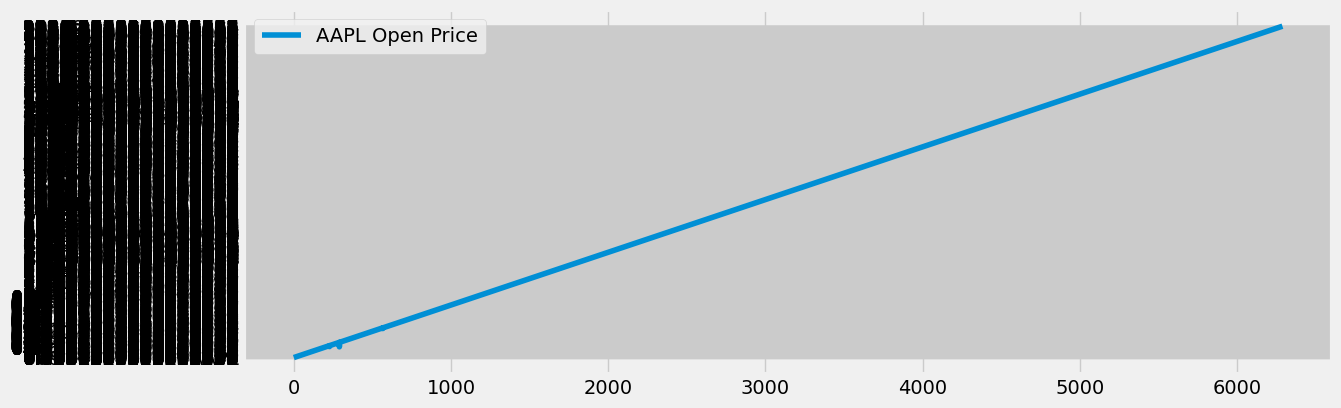

In [165]:
plt.figure(figsize=(12.5,4.5))
plt.plot(range(len(data01)),data01["Open"], label=f"{stock} Open Price")
plt.legend()
plt.show()

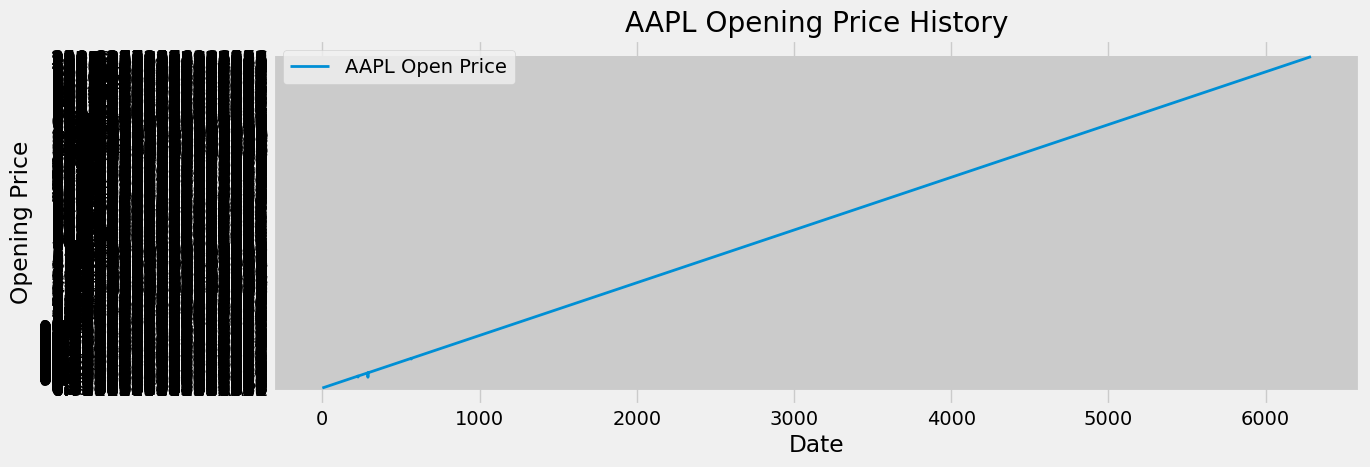

In [161]:
plt.figure(figsize=(12.5,4.5))
plt.plot(data01["Open"], label=f"{stock} Open Price",linewidth=2)
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title(f'{stock} Opening Price History')
plt.legend()
plt.show()

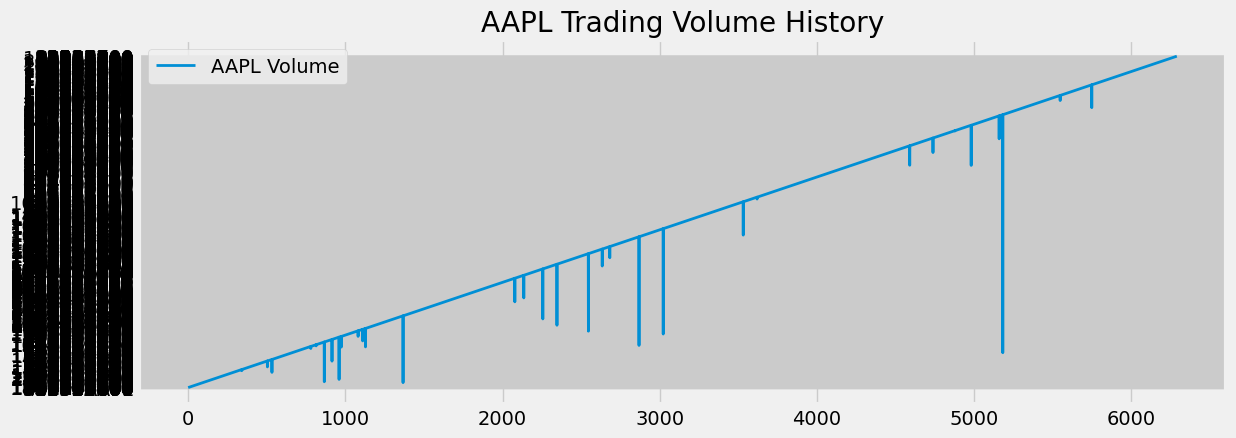

In [169]:
plt.figure(figsize=(12.5,4.5))
plt.plot(data01["Volume"], label=f"{stock} Volume",linewidth=2)
plt.title(f'{stock} Trading Volume History')
plt.legend()
plt.show()

In [172]:
#Moving Average
[10,20,50,100,200]
#moving average for the last 5 days -> null null null null null

temp_data=[10,20,50,100,200]
print(sum(temp_data[0:4])/5)

36.0


In [173]:
import pandas as pd
df01=pd.DataFrame(temp_data)

In [176]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,76.0


In [188]:
ma100=df.Close.rolling(100).mean()

In [189]:
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
6284,228.152033
6285,228.651061
6286,229.136232
6287,229.562041


In [190]:
ma200=df.Close.rolling(200).mean()

In [191]:
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
6284,210.072594
6285,210.501924
6286,210.924608
6287,211.321193


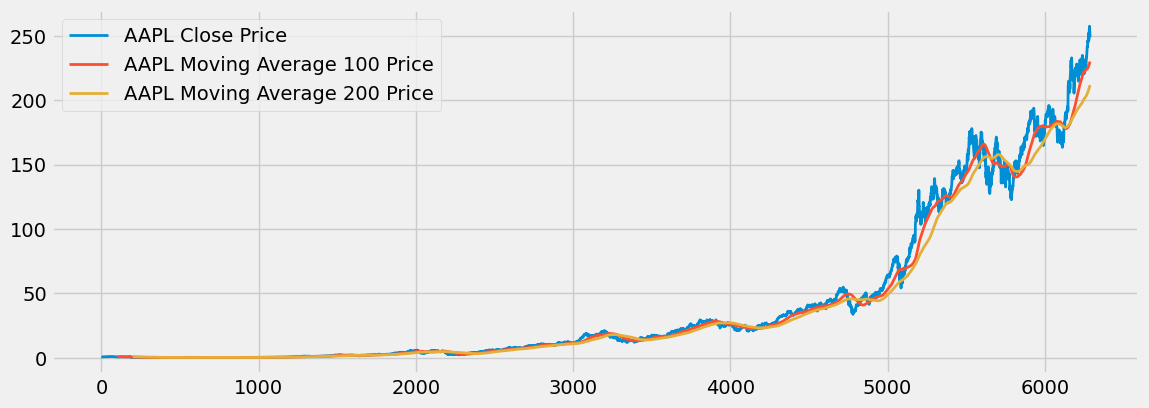

In [192]:
plt.figure(figsize=(12.5,4.5))
plt.plot(df.Close, label=f"{stock} Close Price", linewidth=2)
plt.plot(ma100, label=f"{stock} Moving Average 100 Price", linewidth=2)
plt.plot(ma200, label=f"{stock} Moving Average 200 Price", linewidth=2)
plt.legend()
plt.show()

In [193]:
#NEXT 30-DAYS PREDICTION LSTN
ema100=df.Close.ewm(span=100, adjust=False).mean()
ema200=df.Close.ewm(span=200, adjust=False).mean()

In [194]:
df.pct_change

<bound method NDFrame.pct_change of Price        Date       Close        High         Low        Open     Volume
Ticker                   AAPL        AAPL        AAPL        AAPL       AAPL
0      2000-01-03    0.837724    0.841934    0.761014    0.784869  535796800
1      2000-01-04    0.767096    0.827901    0.757273    0.810127  512377600
2      2000-01-05    0.778320    0.827433    0.770837    0.776450  778321600
3      2000-01-06    0.710966    0.800772    0.710966    0.794225  767972800
4      2000-01-07    0.744644    0.755870    0.714709    0.722192  460734400
...           ...         ...         ...         ...         ...        ...
6284   2024-12-24  256.560791  256.570707  253.669247  253.867989   23234700
6285   2024-12-26  257.375580  258.448740  255.994420  256.550862   27237100
6286   2024-12-27  253.967392  257.057664  251.453455  256.193162   42355300
6287   2024-12-30  250.598923  251.890673  249.158131  250.628731   35557500
6288   2024-12-31  248.830215  251.67205

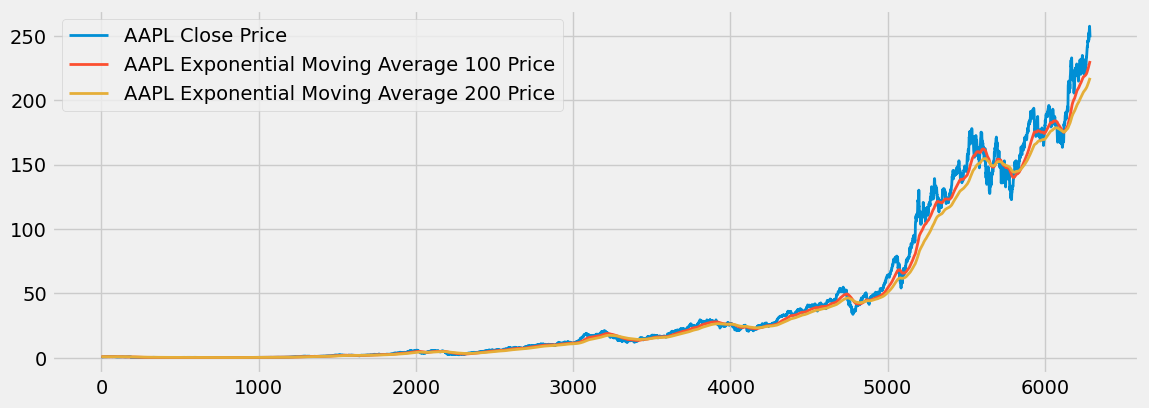

In [195]:
plt.figure(figsize=(12.5,4.5))
plt.plot(df.Close, label=f"{stock} Close Price", linewidth=2)
plt.plot(ema100, label=f"{stock} Exponential Moving Average 100 Price", linewidth=2)
plt.plot(ema200, label=f"{stock} Exponential Moving Average 200 Price", linewidth=2)
plt.legend()
plt.show()

In [196]:
#Traing and testing
data_training=pd.DataFrame(df["Close"][0:int(len(df)*0.7)])
data_testing=pd.DataFrame(df["Close"][int(len(df)*0.7):int(len(df)*0.8)])

In [198]:
data_training.shape


(4402, 1)

In [199]:
data_testing.shape

(629, 1)

In [201]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [202]:
data_training_array=scaler.fit_transform(data_training)

In [203]:
data_training_array

array([[0.0178052 ],
       [0.0158444 ],
       [0.01615602],
       ...,
       [0.93385039],
       [0.92000203],
       [0.92219182]], shape=(4402, 1))

In [204]:
x_train=[]
y_train=[]
for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])
x_train,y_train=np.array(x_train),np.array(y_train)

In [206]:
x_train.shape

(4302, 100, 1)

In [209]:
#Model Building
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

LSTM input -> 3D array -> [batch_size, time_steps, seq_len]
LSTM 2D OR 3D
2D -> (batch_sizem units)
3D -> (batch_size, time_steps, units)

In [210]:
model=Sequential()
model.add(LSTM(units=50,activation="relu",return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation="relu",return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation="relu",return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(units=1))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [211]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
model.compile(optimizer="adam",loss="mean_squared_error")
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - loss: 0.0135
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - loss: 0.0038
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0034
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - loss: 0.0039
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - loss: 0.0031
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - loss: 0.0030
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0031
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0029
Epoch 9/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0026
Epoch 10/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0029
Epoch 11/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0028
Epoch 12/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0028
Epoch 13/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - loss: 0.0027
Epoch 14/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - loss: 0.0025
Epoch 15/50
135

In [222]:
past_100_days=data_training.tail(100)

In [232]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [233]:
final_df.head()

Ticker,AAPL
0,30.376858
1,30.596365
2,30.527039
3,30.797375
4,31.197098


In [234]:
input_data=scaler.fit_transform(final_df)

In [235]:
x_test=[]
y_test=[]
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
x_test,y_test=np.array(x_test),np.array(y_test)

In [236]:
x_test.shape

(629, 100, 1)

In [237]:
y_predicted=model.predict(x_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step


In [239]:
y_predicted.shape

(629, 1)

In [240]:
scaler.scale_

array([0.02478717])

In [241]:
scaler_factor=1/0.02478717
y_predicted=y_predicted*scaler_factor
y_test=y_test*scaler_factor

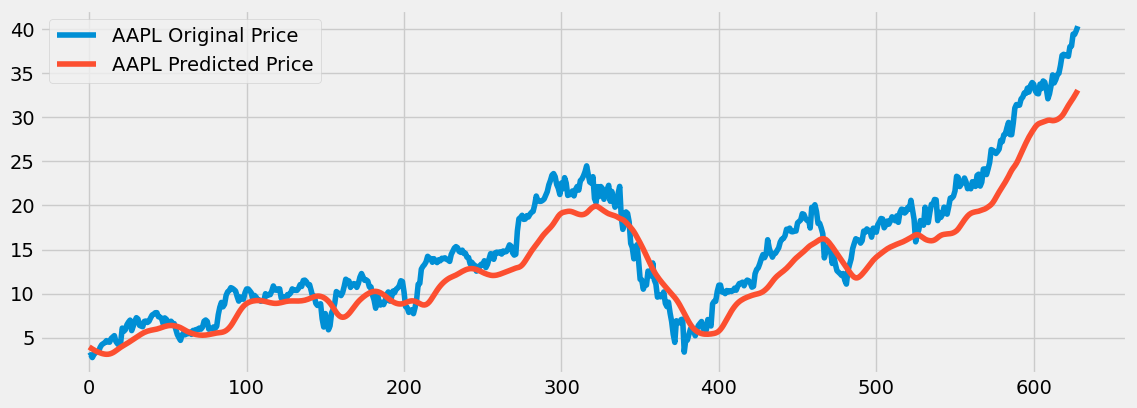

In [242]:
plt.figure(figsize=(12.5,4.5))
plt.plot(y_test, label=f"{stock} Original Price")
plt.plot(y_predicted, label=f"{stock} Predicted Price")
plt.legend()
plt.show()

In [245]:
model.save('stock_d1_model.h5')